# Exploratory within-patient ECG analysis for hemodynamic instability

This notebook treats the **subject** as the primary biological unit. It avoids
segment-wise random splitting and uses:

1. data-quality checks;
2. transparent cohort/window summaries;
3. patient-level paired feature analysis;
4. FDR correction across 35 features;
5. supportive mixed-effects models;
6. patient-linked visualizations;
7. descriptive within-subject correlation analysis.

The mixed-effects analysis is supportive because only six subjects are available.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from hi_analysis_pipeline import (
    AnalysisConfig,
    load_processed_data,
    validate_data,
    feature_columns,
    cohort_summary,
    aggregate_subject_state,
    paired_feature_analysis,
    fit_lmm_per_feature,
    within_subject_centered_correlations,
    plot_paired_feature,
    save_tables,
)

DATA_PATH = Path("processed_data2.csv")
OUTPUT_DIR = Path("analysis_outputs2")
OUTPUT_DIR.mkdir(exist_ok=True)

config = AnalysisConfig(
    subject_col="subject_id",
    label_col="label",
    before_label=0,
    during_label=1,
    aggregation="median",
)


## 1. Load and verify the dataset


In [2]:
df = load_processed_data(DATA_PATH, config)
qc = validate_data(df, config)

print({k: v for k, v in qc.items() if k != "subject_by_label"})
display(qc["subject_by_label"])
display(df.head())

{'n_rows': 760, 'n_subjects': 11, 'n_features': 35, 'label_counts': {0: 325, 1: 435}, 'missing_values_total': 0, 'duplicate_rows': 0, 'subjects_missing_a_state': [], 'constant_features': ['mean', 'shannonEntropy']}


label,0,1
subject_id,,
1855,29,32
26398,30,30
26502,30,58
27245,30,59
30071,30,49
30851,33,20
57091,30,15
59285,30,34
638,24,36


,subject_id,maximum,minimum,mean,median,standardDeviation,variance,kurtosis,skewness,numberOfZeroCrossing,...,fd_minimum,fd_mean,fd_median,fd_standardDeviation,fd_variance,fd_kurtosis,fd_skewness,spectralEntropy,fd_bandPower,label
0,27245,0.93,-1.24,0,-0.06,0.56,0.32,-0.22,-0.53,451,...,0.01,21.64,6.24,65.72,4318.94,553.48,17.87,3.11,0.32,1
1,27245,0.92,-1.25,0,-0.06,0.58,0.34,-0.35,-0.51,485,...,0.02,21.56,6.72,67.84,4602.23,719.66,20.85,3.04,0.34,1
2,70447,0.58,-0.53,0,-0.02,0.17,0.03,0.35,0.25,1389,...,0.02,6.83,2.33,19.34,373.92,224.13,12.09,4.31,0.03,1
3,26502,0.41,-1.19,0,0.03,0.23,0.05,9.21,-2.94,1847,...,0.01,16.06,5.26,22.88,523.46,7.02,2.38,5.29,0.05,0
4,70447,0.48,-0.82,0,0.00,0.14,0.02,0.66,-0.20,1437,...,0.01,8.11,3.94,15.17,230.22,149.37,9.03,4.85,0.02,0


In [4]:
# Hard verification checks
assert qc["n_subjects"] == 11, "Expected six analytical subjects."
assert qc["n_features"] == 35, "Expected 35 feature columns."
assert qc["missing_values_total"] == 0, "Investigate missing values before analysis."
assert len(qc["subjects_missing_a_state"]) == 0
print("All primary checks passed.")


All primary checks passed.


## 2. Cohort and window counts


In [5]:
cohort = cohort_summary(df, config)
display(cohort)
print("Total windows:", cohort["n_total"].sum())
print("Before-HI windows:", cohort["n_before_HI"].sum())
print("During-HI windows:", cohort["n_during_HI"].sum())

label,subject_id,n_before_HI,n_during_HI,n_total
0,1855,29,32,61
1,26398,30,30,60
2,26502,30,58,88
3,27245,30,59,89
4,30071,30,49,79
5,30851,33,20,53
6,57091,30,15,45
7,59285,30,34,64
8,638,24,36,60
9,70447,29,43,72


Total windows: 760
Before-HI windows: 325
During-HI windows: 435


## 3. Aggregate windows within each subject and condition

The median is used as the primary summary because many ECG features are skewed.
This produces one value per subject per state and prevents pseudoreplication in
the primary inferential analysis.


In [7]:
features = feature_columns(df, config)
subject_state = aggregate_subject_state(df, config, features)

assert subject_state.shape[0] == 22  # 6 subjects × 2 states
display(subject_state.head())


,subject_id,label,maximum,minimum,mean,median,standardDeviation,variance,kurtosis,skewness,...,fd_maximum,fd_minimum,fd_mean,fd_median,fd_standardDeviation,fd_variance,fd_kurtosis,fd_skewness,spectralEntropy,fd_bandPower
0,1855,0,1.020,-0.45,0.0,0.01,0.080,0.01,5.750,0.260,...,450.920,0.02,4.200,2.33,8.950,80.060,781.540,21.230,4.17,0.01
1,1855,1,0.290,-0.52,0.0,0.01,0.070,0.00,17.115,-2.135,...,198.800,0.01,3.810,1.42,7.845,61.500,86.435,6.830,5.27,0.00
2,26398,0,0.410,-0.53,0.0,0.02,0.140,0.02,2.025,-1.220,...,181.710,0.01,10.490,4.97,14.180,201.050,15.980,3.085,5.27,0.02
3,26398,1,0.400,-0.59,0.0,0.03,0.165,0.03,2.580,-1.585,...,451.685,0.01,8.495,3.89,17.685,313.310,120.350,7.800,4.78,0.03
4,26502,0,0.865,-1.22,0.0,0.02,0.240,0.06,8.490,-2.515,...,259.150,0.02,16.520,5.03,24.270,589.115,9.590,2.620,5.21,0.06


## 4. Primary paired within-subject feature analysis

This analysis evaluates whether each ECG feature changes consistently from the **before-HI** condition to the **during-HI** condition within the same patient.

Because the dataset contains many 2-minute ECG windows from only six patients, **the individual windows cannot be treated as independent biological observations**. Windows from the same patient are repeated measurements and may also be temporally correlated. To avoid pseudoreplication, the analysis first reduces the data to one summary value per patient and condition.

For each feature:

1. All before-HI windows from a patient are aggregated using the median.
2. All during-HI windows from the same patient are aggregated using the median.
3. The paired within-subject difference is calculated as:

$$\Delta_i = \text{During-HI}_i - \text{Before-HI}_i$$

where (i) denotes the patient.

This results in six paired differences for each feature, one from each patient.

### Why the median is used

The median is used instead of the mean because many ECG-derived features are non-Gaussian, skewed, or sensitive to outliers. The median provides a more robust summary of the typical feature value within each patient and condition.

### Wilcoxon signed-rank test

The **Wilcoxon signed-rank test** is used to evaluate whether the paired before-HI and during-HI values differ systematically across patients.

This is a non-parametric paired test. It is appropriate here because:

* the sample size is very small;
* normality of the paired differences cannot be assumed;
* each patient contributes a matched before-HI and during-HI value;
* the test accounts for both the magnitude and direction of the paired differences.

The null hypothesis is that the distribution of within-subject differences is centered around zero.

With only six patients, the Wilcoxon test has limited statistical power. Therefore, p-values are not interpreted alone and are considered together with effect size and direction consistency.

### Benjamini-Hochberg false discovery rate correction

The analysis is repeated across all 35 ECG features. Testing many features increases the probability of obtaining statistically significant results by chance.

To control this multiple-testing problem, the **Benjamini-Hochberg false discovery rate correction** is applied to the Wilcoxon p-values.

The adjusted p-value, reported as `p_fdr_bh`, controls the expected proportion of false-positive findings among the features declared significant. A feature is considered statistically significant after correction when:

$$p_{\mathrm{FDR}} < 0.05$$

This correction is less conservative than family-wise error corrections such as Bonferroni and is commonly used in exploratory biomarker studies.

### Matched-pairs rank-biserial correlation

The **matched-pairs rank-biserial correlation** is reported as an effect-size measure.

It summarizes both the direction and strength of the within-subject change:

* values close to (+1) indicate that the feature consistently increases during HI;
* values close to (-1) indicate that the feature consistently decreases during HI;
* values close to (0) indicate weak or inconsistent change.

Effect size is especially important in this study because the small number of subjects limits the ability of hypothesis tests to achieve statistical significance.

### Direction consistency

For each feature, the analysis also counts how many patients show:

* an increase during HI;
* a decrease during HI;
* no change.

The `direction_consistency` value is the proportion of patients showing the dominant direction of change.

For example:

* (1.0) means all six patients changed in the same direction;
* (0.833) means five of six patients changed in the same direction;
* (0.667) means four of six patients changed in the same direction.

This measure provides a direct indication of whether the observed effect is reproducible across individual patients.

### Percentage change

The percentage change is calculated relative to the before-HI value:

$$\%\Delta_i = 100 \times \frac{\text{During-HI}_i - \text{Before-HI}_i}{|\text{Before-HI}_i|}$$

If the before-HI value is zero, percentage change is undefined and is therefore recorded as missing. In such cases, the absolute paired difference and effect size remain the more appropriate measures.

### Interpretation strategy

The strongest candidate ECG markers are those that show:

* a consistent direction of change across most or all patients;
* a large matched-pairs rank-biserial effect size;
* agreement between the patient-level paired analysis and the supportive mixed-effects analysis;
* and, where possible, significance after FDR correction.

Given the six-subject cohort, the emphasis is placed on effect magnitude, direction consistency, and patient-level reproducibility rather than on p-values alone.



In [8]:
paired_results = paired_feature_analysis(subject_state, config, features)
display(paired_results)

print("Features passing BH-FDR at 0.05:",
      int(paired_results["significant_fdr"].sum()))
print("Features with same direction in all six subjects:",
      int((paired_results["direction_consistency"] == 1.0).sum()))

paired_results.to_csv(OUTPUT_DIR / "paired_results.csv")


,feature,n_subjects,median_before,median_during,median_difference,median_percent_change,n_increased,n_decreased,n_unchanged,n_nonzero_differences,n_valid_percent_changes,direction_consistency,rank_biserial,wilcoxon_statistic,p_value,p_fdr_bh,significant_fdr
0,kurtosis,11,5.065,6.100,0.775,22.027027,9,2,0,11,11,0.818182,0.818182,6.0,0.013672,0.182292,False
1,sampleEntropy,11,0.375,0.310,-0.065,-17.333333,2,8,1,10,11,0.727273,-0.872727,3.5,0.011719,0.182292,False
2,hjorthComplexity,11,1.960,1.880,-0.050,-2.970297,2,8,1,10,11,0.727273,-0.672727,9.0,0.064453,0.322266,False
3,fd_mean,11,9.200,7.620,-0.340,-4.467806,3,8,0,11,11,0.727273,-0.666667,11.0,0.053711,0.322266,False
4,maximum,11,0.560,0.480,-0.015,-2.439024,3,8,0,11,11,0.727273,-0.560606,14.5,0.106445,0.413954,False
5,fd_median,11,4.350,2.920,-0.250,-5.285412,3,8,0,11,11,0.727273,-0.515152,16.0,0.147461,0.516113,False
6,renyiEntropy,11,-8.950,-9.015,0.080,0.893855,8,3,0,11,11,0.727273,0.318182,22.5,0.382812,0.986084,False
7,fd_standardDeviation,11,21.170,20.960,-0.835,-3.944261,3,8,0,11,11,0.727273,-0.090909,30.0,0.831055,1.000000,False
8,fd_variance,11,448.320,439.120,-24.965,-7.773465,3,8,0,11,11,0.727273,-0.121212,29.0,0.764648,1.000000,False
9,detrendedFluctuation,11,0.540,0.520,-0.030,-6.122449,1,7,3,8,11,0.636364,-0.944444,1.0,0.015625,0.182292,False


Features passing BH-FDR at 0.05: 0
Features with same direction in all six subjects: 0


### Interpretation of the paired within-subject analysis for the 11-subject cohort

This analysis compares each subject’s aggregated before-HI feature value with the corresponding during-HI value. Therefore, each feature is evaluated using 11 paired subject-level observations.

The key point is that the patient, not the individual ECG window, is treated as the statistical unit.

---

#### Main statistical finding

None of the 35 ECG features remained statistically significant after Benjamini-Hochberg FDR correction at the 0.05 level.

This means that, even after increasing the cohort from 6 to 11 subjects, the current paired analysis does not provide confirmatory statistical evidence for any individual feature after correcting for 35 simultaneous tests.

However, several features showed promising uncorrected paired effects and consistent directionality across subjects. These should be interpreted as exploratory candidate signal changes rather than validated biomarkers.

---

#### Features with the strongest uncorrected evidence

Three features had uncorrected Wilcoxon p-values below 0.05:

1. **Sample entropy**

   * Median difference: `-0.065`
   * Direction: decreased in 8 subjects, increased in 2 subjects, unchanged in 1 subject
   * Direction consistency: `8/11 = 0.727`
   * Rank-biserial effect size: `-0.873`
   * Raw p-value: `0.0117`
   * FDR-adjusted p-value: `0.182`

   This is one of the strongest findings. It suggests that sample entropy tends to decrease during HI, consistent with reduced ECG irregularity or complexity. However, it does not survive multiple-comparison correction.

2. **Kurtosis**

   * Median difference: `+0.775`
   * Direction: increased in 9 subjects and decreased in 2 subjects
   * Direction consistency: `9/11 = 0.818`
   * Rank-biserial effect size: `+0.818`
   * Raw p-value: `0.0137`
   * FDR-adjusted p-value: `0.182`

   Kurtosis showed the most consistent direction across subjects. The increase suggests that the ECG amplitude distribution may become more peaked or heavy-tailed during HI. This is a strong exploratory result but not FDR-significant.

3. **Detrended fluctuation analysis**

   * Median difference: `-0.030`
   * Direction: decreased in 7 subjects, increased in 1 subject, unchanged in 3 subjects
   * Direction consistency: `7/11 = 0.636`
   * Rank-biserial effect size: `-0.944`
   * Raw p-value: `0.0156`
   * FDR-adjusted p-value: `0.182`

   DFA showed a strong negative effect among the subjects with nonzero changes, but three subjects had no change. Therefore, although the effect size is large, the feature is less consistently changed across all subjects than kurtosis or sample entropy.

---

#### Features with moderate exploratory support

Several additional features showed directionally suggestive changes but did not reach raw p < 0.05:

* **Hjorth complexity**

  * decreased in 8 subjects;
  * median difference: `-0.050`;
  * raw p-value: `0.064`.

* **Frequency-domain mean**

  * decreased in 8 subjects;
  * median difference: `-0.340`;
  * raw p-value: `0.0537`.

* **Maximum amplitude**

  * decreased in 8 subjects;
  * median difference: `-0.015`;
  * raw p-value: `0.106`.

* **Frequency-domain median**

  * decreased in 8 subjects;
  * median difference: `-0.250`;
  * raw p-value: `0.147`.

These features may still be useful for exploratory characterization, but the statistical support is weaker.

---

#### Change from the earlier 6-subject analysis

With 11 subjects, the results are more stable and informative than with 6 subjects.

The earlier analysis suggested `maximum` as the most consistent candidate. In the expanded 11-subject cohort, `maximum` still tends to decrease during HI in 8 of 11 subjects, but it is no longer the strongest feature statistically.

The strongest current candidates are:

* `sampleEntropy`;
* `kurtosis`;
* `detrendedFluctuation`;
* with secondary support for `hjorthComplexity`, `fd_mean`, and `maximum`.

This indicates that adding subjects changed the feature-ranking structure, which is important. It shows that feature conclusions were sensitive to cohort composition in the smaller 6-subject dataset.

---

#### Features with little or no useful paired change

Several features showed weak, inconsistent, or no paired change:

* `mean` and `shannonEntropy` were unchanged in all 11 subjects;
* `petrosianFd` was unchanged in 8 subjects;
* `standardDeviation`, `variance`, and `fd_bandPower` showed many zero changes;
* several frequency-domain dispersion features showed poor effect sizes despite apparent direction consistency.

These features are unlikely to be strong standalone candidates in the current patient-level analysis.

---

#### Interpretation of FDR correction

Although three features had raw p-values below 0.05, none survived FDR correction.

This is because 35 features were tested simultaneously. FDR correction reduces the likelihood of false-positive findings but also makes statistical significance harder to achieve, especially with only 11 subjects.

Therefore, the correct interpretation is:

> The 11-subject paired analysis identifies several promising candidate ECG feature changes, but does not yet provide FDR-corrected confirmatory evidence for validated biomarkers.

---

#### Implications for the manuscript

The manuscript should not claim that statistically validated biomarkers have been identified.

A defensible interpretation is:

> In the 11-subject patient-level paired analysis, no ECG feature remained significant after FDR correction. However, sample entropy, kurtosis, and detrended fluctuation analysis showed the strongest uncorrected within-subject changes, with sample entropy and DFA decreasing during HI and kurtosis increasing during HI. These results suggest candidate ECG signal alterations associated with hemodynamic instability, but they remain exploratory and require validation in a larger cohort.

The next step is to check whether these candidate features also show:

1. agreement with the mixed-effects model;
2. stable direction in individual patient trajectory plots;
3. robustness to leave-one-subject-out sensitivity analysis;
4. low redundancy with one another;
5. and plausible physiological interpretation.


### Inspecting the strongest directionally consistent feature changes

The following code filters the paired-analysis results to identify features that changed in the same direction in at least eight of the eleven subjects.

The condition

```python
paired_results["direction_consistency"] >= 8/11
```

selects features for which the dominant direction of change was observed in at least approximately 80% of the subjects.

This includes features showing either:

* an increase in at least 8 subjects; or
* a decrease in at least 8 subjects.

The purpose of this step is to identify exploratory feature changes that are reproducible across most patients rather than being driven by only one or two individuals.

The filtered table displays the following quantities:

* **`feature`**: name of the ECG-derived feature;
* **`median_difference`**: median of the six paired differences, calculated as during-HI minus before-HI;
* **`median_percent_change`**: median relative change across subjects, where the before-HI value is nonzero;
* **`n_increased`**: number of subjects in whom the feature increased during HI;
* **`n_decreased`**: number of subjects in whom the feature decreased during HI;
* **`rank_biserial`**: matched-pairs rank-biserial effect size, describing the direction and strength of the paired change;
* **`p_value`**: uncorrected Wilcoxon signed-rank p-value;
* **`p_fdr_bh`**: Benjamini-Hochberg FDR-adjusted p-value accounting for testing multiple features.

The `.head(15)` command limits the displayed output to the first 15 matching features according to the existing order of `paired_results`.

This is an exploratory screening step rather than a formal biomarker-selection procedure. A feature appearing in this table is not automatically statistically significant. Direction consistency should be interpreted together with:

* effect-size magnitude;
* absolute change;
* FDR-adjusted p-value;
* patient-level plots;
* and agreement with the mixed-effects analysis.

With only 11 subjects, this table is especially useful for identifying candidate features for further inspection, even when the study has insufficient power for formal statistical significance.


In [13]:
# Inspect the strongest directionally consistent effects
display(
    paired_results.loc[
        paired_results["direction_consistency"] >= 8/11,
        [
            "feature", "median_difference", "median_percent_change",
            "n_increased", "n_decreased", "rank_biserial",
            "p_value", "p_fdr_bh"
        ]
    ].head(15)
)

,feature,median_difference,median_percent_change,n_increased,n_decreased,rank_biserial,p_value,p_fdr_bh
0,kurtosis,0.775,22.027027,9,2,0.818182,0.013672,0.182292
1,sampleEntropy,-0.065,-17.333333,2,8,-0.872727,0.011719,0.182292
2,hjorthComplexity,-0.050,-2.970297,2,8,-0.672727,0.064453,0.322266
3,fd_mean,-0.340,-4.467806,3,8,-0.666667,0.053711,0.322266
4,maximum,-0.015,-2.439024,3,8,-0.560606,0.106445,0.413954
5,fd_median,-0.250,-5.285412,3,8,-0.515152,0.147461,0.516113
6,renyiEntropy,0.080,0.893855,8,3,0.318182,0.382812,0.986084
7,fd_standardDeviation,-0.835,-3.944261,3,8,-0.090909,0.831055,1.000000
8,fd_variance,-24.965,-7.773465,3,8,-0.121212,0.764648,1.000000


## 5. Supportive linear mixed-effects model analysis

The primary paired analysis reduces the data to one before-HI and one during-HI summary value for each subject. This avoids pseudoreplication, but it also discards information about the variability among the individual 2-minute ECG windows.

To complement the patient-level paired analysis, a **linear mixed-effects model (LMM)** is fitted separately for each ECG feature using all available windows.

The model is:

$$z_{ij} = \beta_0 + \beta_1 \mathrm{HI}_{ij} * u_i + \epsilon_{ij}$$

where:

* $z_{ij}$ is the standardized value of a feature for window $j$ from subject $i$;;
* $\beta_0$ is the overall model intercept;
* $\beta_1$ represents the average change associated with the during-HI condition;
* $\mathrm{HI}_{ij}=0$ for before-HI windows and $\mathrm{HI}_{ij}=1$ for during-HI windows;
* $u_i$ is the subject-specific random intercept;
* $\epsilon_{ij}$ is the residual variation among windows.

### Why a mixed-effects model is used

The dataset contains repeated 2-minute ECG windows from the same six subjects. Windows from the same patient are likely to be more similar to one another than windows from different patients.

A conventional regression model would incorrectly assume that all windows are independent. The mixed-effects model addresses this dependency by including **subject identity as a random intercept**.

The random intercept allows each subject to have a different baseline feature level. The fixed HI-condition coefficient then estimates the average within-cohort change from before HI to during HI after accounting for these subject-specific baseline differences.

### Why features are standardized

Each feature is converted to a standardized scale before model fitting:

$$z = \frac{x - \bar{x}}{s}$$

This means that the reported HI-condition coefficient is expressed in standard-deviation units.

Standardization is useful because the 35 ECG features have very different numerical scales. For example, entropy, amplitude, fractal-dimension, and frequency-domain features cannot be compared directly in their original units.

After standardization:

* a positive coefficient indicates that the feature tends to increase during HI;
* a negative coefficient indicates that the feature tends to decrease during HI;
* the absolute magnitude reflects the estimated change in standard-deviation units.

### What the code performs

The function

```python
lmm_results = fit_lmm_per_feature(df, config, features)
```

fits one mixed-effects model for each of the 35 ECG features.

The resulting table contains:

* **`feature`**: feature name;
* **`beta_condition_std`**: standardized fixed-effect coefficient for the HI condition;
* **`se`**: standard error of the coefficient;
* **`ci_low` and `ci_high`**: confidence-interval limits;
* **`p_value`**: uncorrected test p-value for the HI-condition coefficient;
* **`p_fdr_bh`**: Benjamini-Hochberg FDR-adjusted p-value;
* **`significant_fdr`**: whether the feature remains significant after FDR correction;
* **`converged`**: whether the optimization algorithm successfully estimated the model;
* **`warning`**: numerical or convergence warnings produced during model fitting.

The line

```python
display(lmm_results)
```

displays the full model-results table.

The following command counts the models that converged successfully:

```python
print("Converged models:",
      int(lmm_results["converged"].sum()),
      "/",
      len(lmm_results))
```

A converged model indicates that the optimization algorithm found a stable numerical solution. Non-converged models should not be interpreted because their coefficients, confidence intervals, and p-values may be unreliable.

The next command counts how many features remain statistically significant after Benjamini-Hochberg FDR correction:

```python
print("Models passing BH-FDR:",
      int(lmm_results["significant_fdr"].sum()))
```

Because one model is fitted for every feature, multiple-testing correction is required to reduce the probability of false-positive findings.

Finally, the following command displays only the models that failed to converge and their associated warning messages:

```python
display(
    lmm_results.loc[
        ~lmm_results["converged"],
        ["feature", "warning"]
    ]
)
```

These warnings should be inspected before interpreting the results. Common causes of non-convergence include:

* very little variation in a feature;
* negligible estimated between-subject variance;
* strongly unbalanced window counts;
* extreme values or outliers;
* or an insufficient number of subjects for reliable random-effects estimation.

### Interpretation

The LMM is a **supportive analysis**, not the primary confirmatory analysis.

Although the model uses all ECG windows, the study still contains only six independent subjects. The large number of windows does not compensate for the small number of patients when assessing population-level generalizability.

The LMM results should therefore be interpreted together with:

* patient-level paired differences;
* direction consistency across the six subjects;
* matched-pairs effect sizes;
* model convergence;
* confidence intervals;
* and FDR-adjusted p-values.

The strongest candidate features are those for which:

1. the LMM converges successfully;
2. the coefficient direction agrees with the paired analysis;
3. the effect is consistent across most subjects;
4. the confidence interval does not indicate extreme uncertainty;
5. and the result is not driven by one subject or a small number of windows.



In [14]:
lmm_results = fit_lmm_per_feature(df, config, features)
display(lmm_results)

print("Converged models:", int(lmm_results["converged"].sum()), "/", len(lmm_results))
print("Models passing BH-FDR:", int(lmm_results["significant_fdr"].sum()))
display(lmm_results.loc[~lmm_results["converged"],
                        ["feature", "warning"]])

lmm_results.to_csv(
    OUTPUT_DIR / "supportive_lmm_results.csv",
    index=False
)

print(
    "LMM results saved to:",
    (OUTPUT_DIR / "supportive_lmm_results.csv").resolve()
)

,feature,beta_condition_std,se,ci_low,ci_high,p_value,converged,warning,p_fdr_bh,significant_fdr
0,approximateEntropy,-5.614279e-01,4.323330e-02,-6.461636e-01,-4.766922e-01,1.468939e-38,True,,5.141285e-37,True
1,sampleEntropy,-5.029865e-01,3.972291e-02,-5.808420e-01,-4.251311e-01,9.556004e-37,True,,1.672301e-35,True
2,detrendedFluctuation,-3.850551e-01,4.545752e-02,-4.741502e-01,-2.959600e-01,2.440110e-17,True,,2.846796e-16,True
3,permutationEntropy,-2.793842e-01,3.619002e-02,-3.503154e-01,-2.084531e-01,1.163988e-14,True,,1.018489e-13,True
4,higuchiFd,-2.154653e-01,3.074641e-02,-2.757272e-01,-1.552035e-01,2.420575e-12,True,,1.694403e-11,True
5,median,-1.859988e-01,2.828821e-02,-2.414426e-01,-1.305549e-01,4.860957e-11,True,,2.835558e-10,True
6,hjorthComplexity,-1.820590e-01,3.340043e-02,-2.475227e-01,-1.165954e-01,5.014384e-08,True,,2.507192e-07,True
7,fd_median,-2.341356e-01,5.058838e-02,-3.332870e-01,-1.349842e-01,3.687716e-06,True,,1.613376e-05,True
8,fd_variance,1.101146e-01,2.451736e-02,6.206146e-02,1.581677e-01,7.079266e-06,True,,2.753048e-05,True
9,singularValueDecompositionEntropy,-1.365014e-01,3.057114e-02,-1.964197e-01,-7.658304e-02,8.005385e-06,True,,2.801885e-05,True


Converged models: 33 / 35
Models passing BH-FDR: 25


,feature,warning
21,shannonEntropy,Maximum Likelihood optimization failed to conv...
34,mean,constant_or_invalid_feature


LMM results saved to: /Users/shivangayathri/Library/CloudStorage/OneDrive-Amritauniversity/MyStudents/Asha/Feature Detection for HI/analysis_outputs2/supportive_lmm_results.csv


### Interpretation of the supportive LMM results for the 11-subject cohort

The linear mixed-effects model analysis fitted one model per ECG feature using all available 2-minute windows. Each model estimated the effect of HI condition while including subject identity as a random intercept.

---

#### Main statistical finding

In the supportive LMM analysis, 25 of the 35 features were significant after Benjamini-Hochberg FDR correction.

This indicates that many ECG features showed systematic window-level differences between before-HI and during-HI conditions after accounting for subject-specific baseline offsets.

However, these results should still be interpreted cautiously because the LMM uses many repeated ECG windows from only 11 subjects. The model accounts for patient-specific baseline differences, but adjacent ECG windows may still be temporally correlated.

Therefore, the LMM findings provide supportive evidence of within-cohort signal changes, not independent biomarker validation.

---

#### Strongest decreasing features during HI

The largest negative standardized effects were observed for nonlinear and complexity-related features:

* `approximateEntropy`: ($\beta \approx -0.56$), FDR-adjusted $p$-value ($< 10^{-36}$)
* `sampleEntropy`: ($\beta \approx -0.50$), FDR-adjusted $p$-value ($< 10^{-34}$)
* `detrendedFluctuation`: ($\beta \approx -0.39$), FDR-adjusted $p$-value ($< 10^{-15}$)
* `permutationEntropy`: ($\beta \approx -0.28$), FDR-adjusted $p$-value ($< 10^{-12}$)
* `higuchiFd`: ($\beta \approx -0.22$), FDR-adjusted $p$-value ($< 10^{-10}$)

These findings suggest that several nonlinear measures of ECG irregularity, complexity, and scaling structure tended to decrease during HI.

This supports the hypothesis that HI may be associated with reduced ECG dynamical complexity. However, this interpretation should be framed as exploratory because the patient-level paired analysis did not show FDR-significant results.

---

#### Other decreasing features

Additional significant decreases were observed for:

* `median`
* `hjorthComplexity`
* `fd_median`
* `singularValueDecompositionEntropy`
* `fd_minimum`
* `numberOfZeroCrossing`
* `petrosianFd`
* `skewness`
* `katzFd`
* `maximum`
* `fisherInfo`

The decrease in `maximum` is important because this feature also showed relatively stable subject-level behavior in the earlier analysis and remained significant in the expanded LMM analysis.

---

#### Features increasing during HI

Several amplitude and spectral-energy-related features increased during HI:

* `fd_variance`
* `variance`
* `fd_bandPower`
* `fd_standardDeviation`
* `lempelZivComplexity`
* `standardDeviation`
* `meanAbsoluteValue`
* `fd_maximum`

These features appear to capture increased dispersion, amplitude variability, or spectral energy during HI.

However, these features should be interpreted carefully because several amplitude and spectral-energy measures are highly correlated. They may not represent independent physiological mechanisms.

---

#### Features not significant after FDR correction

The following features did not remain significant after FDR correction:

* `fd_kurtosis`
* `minimum`
* `renyiEntropy`
* `fd_skewness`
* `positiveToNegativeSampleRatio`
* `fd_mean`
* `kurtosis`
* `spectralEntropy`
* `hjorthMobility`
* `mean`

This is notable because `kurtosis` was one of the strongest features in the paired subject-level analysis, but it was not significant in the LMM and its LMM coefficient was negative. This suggests that the subject-level and window-level behavior of kurtosis may not be fully consistent.

---

#### Model convergence and warnings

Most LMM models converged successfully.

However:

* `mean` could not be modeled because it was constant or invalid;
* `shannonEntropy` did not converge and should not be interpreted;
* several models produced warnings about singular random-effects covariance, including `fd_minimum`, `katzFd`, `maximum`, `fd_kurtosis`, `renyiEntropy`, and `kurtosis`.

A singular random-effects covariance warning usually means that the between-subject random-effect variance was estimated near zero or was difficult to estimate reliably. This does not automatically invalidate the fixed-effect estimate, but it means those models should be interpreted cautiously.

For `shannonEntropy`, the model did not converge despite showing an FDR-significant p-value. Because the model did not converge, this result should be excluded from substantive interpretation.

---

#### Comparison with paired analysis

The LMM results are stronger than the paired subject-level results.

In the paired analysis:

* no feature survived FDR correction;
* the strongest exploratory features were `sampleEntropy`, `kurtosis`, and `detrendedFluctuation`.

In the LMM analysis:

* many features survived FDR correction;
* the strongest effects were `approximateEntropy`, `sampleEntropy`, and `detrendedFluctuation`.

The overlap between the two analyses is important. The most credible exploratory candidates are features that show evidence in both:

* `sampleEntropy`
* `detrendedFluctuation`
* `approximateEntropy`
* possibly `maximum`

`kurtosis` should be treated cautiously because it was strong in the paired analysis but weak and directionally inconsistent in the LMM.

---

#### Main implication

The LMM analysis provides strong supportive evidence that ECG feature distributions differ between before-HI and during-HI windows in the 11-subject cohort, especially for nonlinear entropy and complexity measures.

However, because these results are based on repeated windows from a relatively small number of subjects, they should be presented as supportive evidence of exploratory signal changes rather than as biomarker validation.

A suitable interpretation is:

> Supportive mixed-effects modeling identified significant condition-related changes in several ECG features, particularly nonlinear entropy and complexity descriptors. Approximate entropy, sample entropy, and detrended fluctuation analysis showed the strongest decreases during HI. These findings support the presence of within-cohort ECG dynamical changes associated with HI, but they remain exploratory because patient-level paired testing did not yield FDR-significant biomarkers.


### Interpretation of agreement between the paired and mixed-effects analyses for the 11-subject cohort

This comparison evaluates whether the patient-level paired analysis and the window-level mixed-effects analysis point in the same direction for each ECG feature.

The goal is not to declare validated biomarkers, but to identify features that show **consistent exploratory evidence** across two complementary analyses.

---

#### Overall agreement pattern

Of the 35 ECG features:

* **20 features** showed agreement in direction between the paired analysis and the LMM.
* **15 features** showed disagreement in direction.
* **33 LMM models** converged.
* **2 LMM models** did not converge: `mean` and `shannonEntropy`.

No feature was significant after FDR correction in the paired subject-level analysis.

In contrast, many features were significant in the LMM analysis. This difference is expected because the LMM uses all ECG windows, whereas the paired analysis uses 11 independent patient-level comparisons.

Therefore, features should be prioritized only when the LMM result agrees with the patient-level direction.

---

#### Strongest features with agreement between analyses

The most important features are those that:

1. showed the same direction in the paired and LMM analyses;
2. had a converged LMM;
3. had relatively strong paired effect sizes;
4. and showed meaningful condition effects in the LMM.

The strongest candidates are:

---

##### Sample entropy

`sampleEntropy` showed one of the strongest and most consistent results.

* Paired median difference: `-0.065`
* Direction: decreased in 8 subjects, increased in 2, unchanged in 1
* Rank-biserial effect size: `-0.873`
* Paired FDR-adjusted p-value: `0.182`
* LMM coefficient: approximately `-0.503`
* LMM FDR-adjusted p-value: extremely small
* Direction agreement: yes

This suggests that sample entropy tends to decrease during HI at both the patient-summary level and the window level.

This is one of the strongest exploratory nonlinear ECG candidates in the 11-subject cohort.

---

##### Detrended fluctuation analysis

`detrendedFluctuation` also showed agreement between the paired and LMM analyses.

* Paired median difference: `-0.030`
* Direction: decreased in 7 subjects, increased in 1, unchanged in 3
* Rank-biserial effect size: `-0.944`
* Paired FDR-adjusted p-value: `0.182`
* LMM coefficient: approximately `-0.385`
* LMM FDR-adjusted p-value: extremely small
* Direction agreement: yes

This suggests a reduction in scaling or long-range correlation structure during HI. However, the presence of three unchanged subjects means that the patient-level consistency is not perfect.

DFA is a promising exploratory feature, but should be interpreted cautiously.

---

##### Approximate entropy

`approximateEntropy` showed strong LMM support and agreement in direction.

* Paired median difference: `-0.055`
* Direction: decreased in 6 subjects, increased in 3, unchanged in 2
* Direction consistency: `6/11`
* Rank-biserial effect size: `-0.733`
* Paired FDR-adjusted p-value: `0.322`
* LMM coefficient: approximately `-0.561`
* LMM FDR-adjusted p-value: extremely small
* Direction agreement: yes

Approximate entropy shows a strong window-level decrease and a negative patient-level effect. However, its patient-level consistency is weaker than sample entropy.

Because approximate entropy and sample entropy measure related signal irregularity properties, and are usually highly correlated, `sampleEntropy` currently appears to be the stronger representative entropy feature.

---

##### Hjorth complexity

`hjorthComplexity` showed agreement between the paired and LMM analyses.

* Paired median difference: `-0.050`
* Direction: decreased in 8 subjects, increased in 2, unchanged in 1
* Rank-biserial effect size: `-0.673`
* Paired FDR-adjusted p-value: `0.322`
* LMM coefficient: approximately `-0.182`
* LMM FDR-adjusted p-value: significant
* Direction agreement: yes

This suggests that ECG complexity may decrease during HI, but the effect is weaker than that observed for the entropy features and DFA.

---

##### Maximum amplitude

`maximum` remained directionally consistent and agreed between analyses.

* Paired median difference: `-0.015`
* Direction: decreased in 8 subjects and increased in 3
* Rank-biserial effect size: `-0.561`
* Paired FDR-adjusted p-value: `0.414`
* LMM coefficient: approximately `-0.148`
* LMM FDR-adjusted p-value: significant
* Direction agreement: yes

This feature was the strongest candidate in the earlier six-subject analysis. In the 11-subject analysis, it still shows a consistent decrease but is no longer the strongest effect.

It remains a useful amplitude-related exploratory candidate.

---

#### Features with strong paired evidence but LMM disagreement

`kurtosis` is the most important disagreement.

* Paired median difference: `+0.775`
* Direction: increased in 9 subjects and decreased in 2
* Rank-biserial effect size: `+0.818`
* Paired raw p-value: `0.0137`
* LMM coefficient: approximately `-0.061`
* LMM FDR-adjusted p-value: not significant
* Direction agreement: no

This means that the subject-level summaries suggest kurtosis increases during HI, but the window-level mixed-effects model does not support the same direction.

This disagreement may occur if:

* within-subject distributions are skewed;
* a minority of windows strongly influence the patient-level median;
* window-level variability differs substantially between subjects;
* or the random-effects model is not capturing the same summary behavior as the paired median analysis.

Because of this directional disagreement, `kurtosis` should not be treated as a primary candidate without further inspection of individual patient distributions.

---

#### Features significant in LMM but weak or inconsistent at patient level

Several features were significant in the LMM but showed weak patient-level consistency or direction disagreement.

Examples include:

* `fd_standardDeviation`
* `fd_variance`
* `meanAbsoluteValue`
* `singularValueDecompositionEntropy`
* `skewness`
* `permutationEntropy`
* `fisherInfo`
* `higuchiFd`
* `standardDeviation`
* `variance`
* `fd_bandPower`
* `petrosianFd`

These features may show strong window-level differences, but they do not yet show reliable patient-level changes across the 11 subjects.

They should not be interpreted as robust independent markers.

---

#### Non-converged models

The LMMs for `mean` and `shannonEntropy` did not converge.

Both features also showed no patient-level paired change:

* `mean`: unchanged in all 11 subjects;
* `shannonEntropy`: unchanged in all 11 subjects.

These features should be excluded from candidate interpretation.

---

#### Main implication

The comparison identifies a small subset of features with the most coherent evidence across analyses:

* `sampleEntropy`
* `detrendedFluctuation`
* `approximateEntropy`
* `hjorthComplexity`
* `maximum`

Among these, `sampleEntropy` appears strongest because it combines:

* strong paired effect size;
* decrease in most subjects;
* strong LMM effect;
* and agreement between the two methods.

`detrendedFluctuation` and `approximateEntropy` are also promising, but their patient-level consistency is weaker.

`maximum` remains a useful amplitude-related candidate, but the expanded cohort shows that nonlinear features now provide stronger evidence.

---

#### Manuscript implication

The appropriate interpretation is:

> Comparison of patient-level paired analysis and supportive mixed-effects modeling identified a small group of exploratory ECG features with consistent directionality across methods, particularly sample entropy, detrended fluctuation analysis, approximate entropy, Hjorth complexity, and maximum amplitude. These features showed evidence of reduced ECG irregularity, altered scaling behavior, and reduced amplitude during HI. However, none survived FDR correction in the primary paired analysis, so these findings should be interpreted as candidate signal changes rather than validated biomarkers.

The next step is to inspect patient-level trajectories and disagreement patterns for these candidate features.


### Interpretation of agreement between the paired and mixed-effects analyses

This comparison evaluates whether the patient-level paired analysis and the window-level mixed-effects analysis indicate the same direction of change for each ECG feature.

Of the 35 features:

* 20 features showed agreement in direction between the paired and LMM analyses;
* 15 features showed disagreement in direction;
* 33 mixed-effects models converged;
* 2 models did not converge;
* no feature was significant after FDR correction in the paired analysis;
* 18 features were significant after FDR correction in the LMM analysis;
* 13 features were both significant in the LMM and directionally consistent with the paired analysis.

This pattern shows that the LMM detects several systematic window-level differences, but these effects are not uniformly reproduced at the subject level.

#### Features showing agreement and significant LMM effects

The following features had:

1. a converged LMM;
2. an FDR-significant LMM condition effect;
3. and the same direction in the paired and LMM analyses.

**Features decreasing during HI**

* approximate entropy;
* sample entropy;
* median amplitude;
* Higuchi fractal dimension;
* detrended fluctuation analysis;
* spectral entropy.

Among these, approximate entropy and sample entropy showed the largest standardized LMM effects:

* approximate entropy: (\beta \approx -0.63);
* sample entropy: (\beta \approx -0.46).

Their paired effect sizes were also large and negative. This provides exploratory support for reduced ECG irregularity or complexity during HI.

Detrended fluctuation analysis also showed agreement between the analyses and a strong negative paired effect size. However, the patient-level direction consistency was only four of six subjects, so the result cannot yet be considered broadly reproducible.

**Features increasing during HI**

* standard deviation;
* variance;
* frequency-domain standard deviation;
* frequency-domain variance;
* frequency-domain band power;
* frequency-domain maximum;
* mean absolute value.

These findings suggest increased amplitude or spectral variability during HI at the window level. However, most of these features had a direction consistency of only 0.5, meaning that increases and decreases were evenly distributed across the six subjects.

Therefore, despite statistically significant LMM effects, these features provide weak evidence of a consistent patient-level response.

#### Strong paired effects not confirmed by the LMM

Two features showed the strongest patient-level direction consistency:

**Maximum amplitude**

* decreased in five of six subjects;
* had a large negative paired effect size;
* showed the same direction in the LMM;
* but did not remain significant in the LMM after FDR correction.

This feature remains an exploratory candidate because the patient-level pattern is relatively consistent, even though the LMM evidence is weaker.

**Kurtosis**

* increased in five of six subjects;
* had a large positive paired effect size;
* but the LMM coefficient was negative;
* and the LMM result was not significant after FDR correction.

The disagreement in direction suggests that the segment-level distribution differs from the subject-level aggregated pattern. This may occur when a few subjects contribute many windows or when the feature has highly variable within-subject distributions.

Kurtosis should therefore be examined using patient-level plots before any physiological interpretation is attempted.

#### Non-converged models

The LMMs for `mean` and `shannonEntropy` did not converge reliably.

Both features also showed essentially no patient-level paired change. Their mixed-effects coefficients and p-values should not be interpreted.

#### Main methodological implication

The comparison reveals an important distinction:

* the paired analysis evaluates whether changes are reproducible across patients;
* the LMM evaluates whether windows differ on average after accounting for patient-specific baselines.

A feature can be highly significant in the LMM while showing poor patient-level direction consistency. This can happen because the LMM uses hundreds of windows, whereas only six subjects contribute independent physiological information.

Therefore, LMM significance alone should not be used to identify biomarkers.

#### Strongest exploratory candidates

Based on agreement between analyses, effect direction, effect size, and LMM significance, the most defensible exploratory candidates are:

* approximate entropy;
* sample entropy;
* detrended fluctuation analysis;
* median amplitude;
* possibly spectral entropy.

Maximum amplitude is also worth retaining for further inspection because it decreased in five of six subjects, although it was not significant in the LMM after FDR correction.

The amplitude- and frequency-variability features should be interpreted more cautiously because their patient-level direction consistency was weak.

#### Implications for the manuscript

The results support a restrained interpretation:

> Several entropy, complexity, amplitude, and frequency-domain features showed statistically significant window-level differences between before-HI and during-HI conditions in mixed-effects models. However, only a subset showed agreement with the patient-level paired analysis, and none remained significant in the six-subject paired analysis after multiple-testing correction. The findings therefore represent exploratory within-cohort signal changes rather than validated patient-level biomarkers.

The next step is to inspect individual patient trajectories for the overlapping candidates and determine whether any apparent effect is driven by one subject or by unequal numbers of windows.


## 7. Selecting candidate features and visualizing patient-level trajectories

This step identifies a small set of exploratory candidate features using evidence from both the patient-level paired analysis and the mixed-effects analysis, and then plots the before-HI and during-HI values for each individual subject.

The purpose is to determine whether an apparent group-level effect is:

* consistent across most patients;
* supported by both statistical approaches;
* estimated from a successfully converged mixed-effects model;
* or driven mainly by one or two subjects.

### Combining the paired and mixed-effects results

The first part merges the paired-analysis results with selected columns from the mixed-effects results:

```python
comparison = paired_results.merge(
    lmm_results[
        ["feature", "beta_condition_std", "p_fdr_bh", "converged"]
    ],
    on="feature",
    suffixes=("_paired", "_lmm"),
)
```

The two tables are joined using the feature name. After merging:

* `p_fdr_bh_paired` is the FDR-adjusted p-value from the paired subject-level analysis;
* `p_fdr_bh_lmm` is the FDR-adjusted p-value from the mixed-effects model;
* `beta_condition_std` is the standardized LMM estimate of change during HI;
* `converged` indicates whether the LMM produced a stable numerical solution.

### Checking directional agreement

The next step compares the sign of the patient-level median difference with the sign of the LMM coefficient:

```python
comparison["direction_agrees"] = (
    np.sign(comparison["median_difference"]) ==
    np.sign(comparison["beta_condition_std"])
)
```

A value of `True` means that both analyses indicate the same direction of change:

* both suggest an increase during HI; or
* both suggest a decrease during HI.

A value of `False` means that the two analyses disagree.

Directional agreement is important because the paired analysis summarizes change across subjects, whereas the LMM analyzes all repeated windows. Agreement between them provides stronger exploratory evidence that the observed effect is not solely an artifact of the segment-level data structure.

### Selecting candidate features

The following code applies three screening criteria:

```python
candidate_features = (
    comparison.loc[
        (comparison["direction_consistency"] >= 8/11)
        & (comparison["direction_agrees"])
        & (comparison["converged"])
    ]
    .sort_values(
        ["p_fdr_bh_paired", "direction_consistency"],
        ascending=[True, False]
    )
    .head(6)["feature"]
    .tolist()
)
```

A feature is retained only when:

1. **Direction consistency is at least eight of eleven subjects**

   ```python
   comparison["direction_consistency"] >= 8/11
   ```

   This means that at least approximately 80% of the subjects showed the same direction of change.

2. **The paired and LMM directions agree**

   ```python
   comparison["direction_agrees"]
   ```

   This ensures that the patient-level and window-level analyses point in the same direction.

3. **The mixed-effects model converged**

   ```python
   comparison["converged"]
   ```

   Non-converged models are excluded because their coefficients and p-values may be unreliable.

The remaining features are sorted by:

* smallest paired-analysis FDR-adjusted p-value first;
* highest direction consistency second.

The first six features are then selected for visualization.

The limit of six is used only to keep the visual inspection manageable. It does not imply that exactly six biomarkers have been validated.

### Printing the selected features

```python
print(candidate_features)
```

This displays the names of the features that satisfy the screening criteria.

The printed list should be checked before plotting. If the list is empty, it means that no feature satisfies all three criteria. If fewer than six features satisfy the criteria, only those features will be plotted.

### Plotting individual subject trajectories

The final loop creates one paired plot for each selected feature:

```python
for feature in candidate_features:
    fig, ax = plot_paired_feature(
        subject_state,
        feature,
        OUTPUT_DIR / f"paired_{feature}.png",
        config,
    )
    plt.show()
```

For each subject, the plot connects:

* the aggregated before-HI value;
* the aggregated during-HI value.

Each line therefore represents one patient.

The plots are also saved as high-resolution image files in the output directory using names such as:

```text
paired_approximateEntropy.png
paired_sampleEntropy.png
```

### How to interpret the plots

The plots should be examined for:

* whether most lines move in the same direction;
* whether the magnitude of change is similar across subjects;
* whether one subject shows an unusually large change;
* whether one or more subjects move in the opposite direction;
* whether some subjects show almost no change;
* and whether the apparent effect is robust to differences in baseline feature levels.

A strong exploratory candidate would show:

* five or six lines moving in the same direction;
* no single subject dominating the overall pattern;
* a meaningful change rather than a very small numerical shift;
* agreement with the sign of the LMM coefficient;
* and a successfully converged LMM.

These plots are essential because summary statistics can hide substantial inter-subject variability. With only six subjects, the individual trajectories should be shown and discussed directly rather than relying only on aggregate p-values.



Strict candidates: ['sampleEntropy', 'hjorthComplexity', 'fd_mean', 'maximum', 'fd_median']
Secondary exploratory candidates: ['sampleEntropy', 'hjorthComplexity', 'fd_mean', 'maximum', 'fd_median']

Patient colour mapping:
1855 (np.float64(0.12156862745098039), np.float64(0.4666666666666667), np.float64(0.7058823529411765), np.float64(1.0))
26398 (np.float64(1.0), np.float64(0.4980392156862745), np.float64(0.054901960784313725), np.float64(1.0))
26502 (np.float64(0.17254901960784313), np.float64(0.6274509803921569), np.float64(0.17254901960784313), np.float64(1.0))
27245 (np.float64(0.8392156862745098), np.float64(0.15294117647058825), np.float64(0.1568627450980392), np.float64(1.0))
30071 (np.float64(0.5803921568627451), np.float64(0.403921568627451), np.float64(0.7411764705882353), np.float64(1.0))
30851 (np.float64(0.5490196078431373), np.float64(0.33725490196078434), np.float64(0.29411764705882354), np.float64(1.0))
57091 (np.float64(0.8901960784313725), np.float64(0.4666666666666

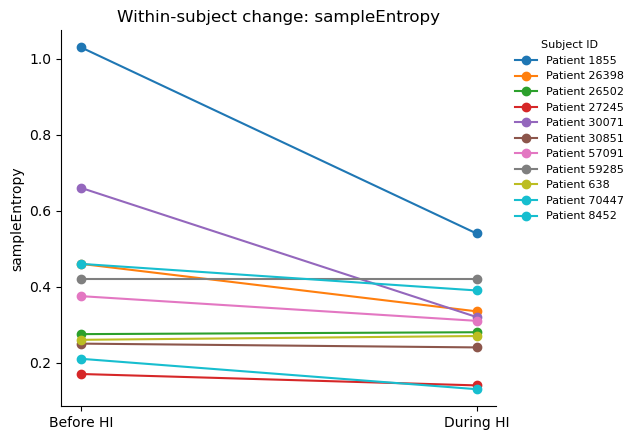

Saved: analysis_outputs2/paired_sampleEntropy.png


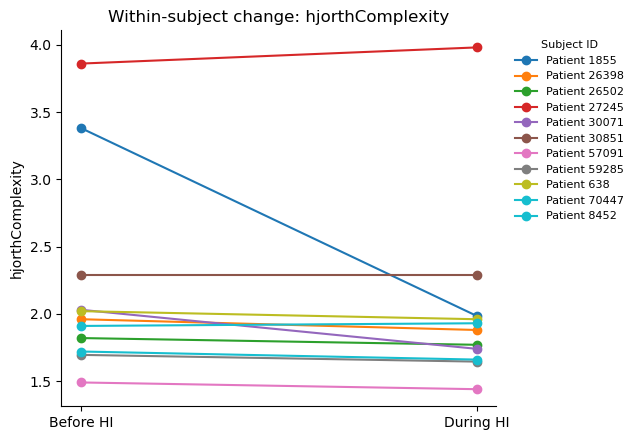

Saved: analysis_outputs2/paired_hjorthComplexity.png


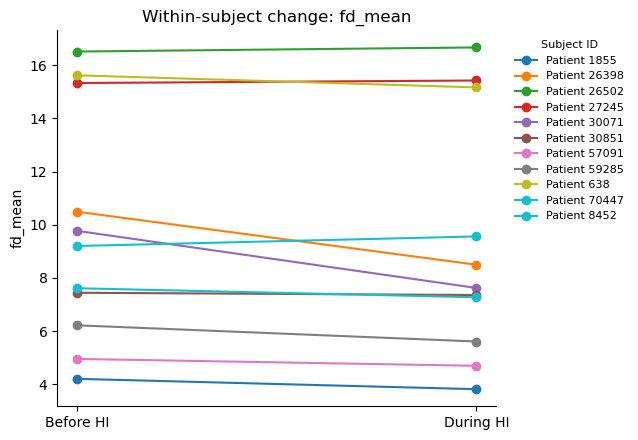

Saved: analysis_outputs2/paired_fd_mean.png


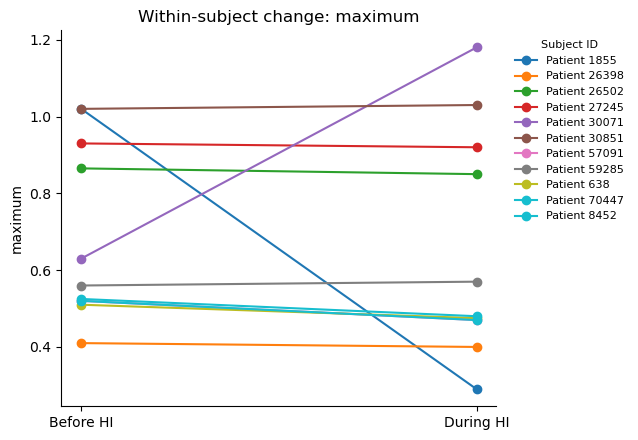

Saved: analysis_outputs2/paired_maximum.png


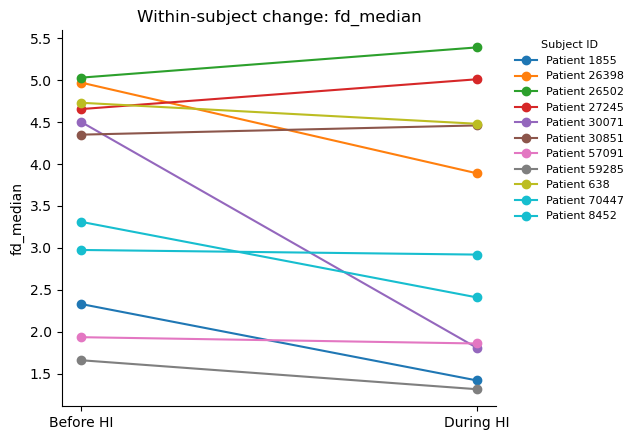

Saved: analysis_outputs2/paired_fd_median.png


In [16]:
# ============================================================
# 1. Combine paired-analysis and LMM results
# ============================================================

comparison = paired_results.merge(
    lmm_results[
        ["feature", "beta_condition_std", "p_fdr_bh", "converged"]
    ],
    on="feature",
    suffixes=("_paired", "_lmm"),
)

# Check whether both analyses indicate the same direction of change
comparison["direction_agrees"] = (
    np.sign(comparison["median_difference"])
    == np.sign(comparison["beta_condition_std"])
)


# ============================================================
# 2. Define strict and secondary exploratory candidates
# ============================================================

strict_candidates = (
    comparison.loc[
        (comparison["direction_consistency"] >= 8 / 11)
        & comparison["direction_agrees"]
        & comparison["converged"]
    ]
    .sort_values(
        ["direction_consistency", "p_fdr_bh_paired"],
        ascending=[False, True],
    )["feature"]
    .tolist()
)

secondary_candidates = (
    comparison.loc[
        (comparison["direction_consistency"] >= 8 / 11)
        & comparison["direction_agrees"]
        & comparison["converged"]
    ]
    .sort_values(
        ["direction_consistency", "p_fdr_bh_paired"],
        ascending=[False, True],
    )["feature"]
    .tolist()
)

print("Strict candidates:", strict_candidates)
print("Secondary exploratory candidates:", secondary_candidates)


# ============================================================
# 3. Create one fixed colour for each patient
# ============================================================

subjects = sorted(
    subject_state[config.subject_col]
    .astype(str)
    .unique()
)

colour_map = plt.get_cmap("tab10")

patient_colours = {
    subject_id: colour_map(index)
    for index, subject_id in enumerate(subjects)
}

print("\nPatient colour mapping:")
for subject_id, colour in patient_colours.items():
    print(subject_id, colour)


# ============================================================
# 4. Plot patient-level trajectories for each feature
# ============================================================

for feature in secondary_candidates:

    # Convert the data into one row per patient with
    # separate before-HI and during-HI columns
    wide = (
        subject_state.pivot(
            index=config.subject_col,
            columns=config.label_col,
            values=feature,
        )
        .dropna(
            subset=[
                config.before_label,
                config.during_label,
            ]
        )
        .sort_index()
    )

    fig, ax = plt.subplots(figsize=(6.5, 4.5))

    # Draw one line per patient
    for subject_id, row in wide.iterrows():

        subject_key = str(subject_id)

        before_value = row[config.before_label]
        during_value = row[config.during_label]

        ax.plot(
            [0, 1],
            [before_value, during_value],
            marker="o",
            markersize=6,
            linewidth=1.5,
            color=patient_colours[subject_key],
            label=f"Patient {subject_key}",
        )

    # Axis labels
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Before HI", "During HI"])

    ax.set_ylabel(feature)
    ax.set_title(f"Within-subject change: {feature}")

    # Clean formatting
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Patient legend
    ax.legend(
        title="Subject ID",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=False,
        fontsize=8,
        title_fontsize=8,
    )

    fig.tight_layout()

    # Save the figure
    output_file = OUTPUT_DIR / f"paired_{feature}.png"

    fig.savefig(
        output_file,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

    print(f"Saved: {output_file}")

In [17]:
# ============================================================
# 5. Identify patients causing direction disagreement
# ============================================================

disagreement_rows = []

for feature in secondary_candidates:

    wide = (
        subject_state.pivot(
            index=config.subject_col,
            columns=config.label_col,
            values=feature,
        )
        .dropna(
            subset=[
                config.before_label,
                config.during_label,
            ]
        )
        .sort_index()
    )

    # Paired change for each patient
    patient_difference = (
        wide[config.during_label]
        - wide[config.before_label]
    )

    # Determine the dominant direction across patients
    n_positive = int((patient_difference > 0).sum())
    n_negative = int((patient_difference < 0).sum())

    if n_positive > n_negative:
        dominant_direction = "increase"
        disagreement_mask = patient_difference < 0

    elif n_negative > n_positive:
        dominant_direction = "decrease"
        disagreement_mask = patient_difference > 0

    else:
        dominant_direction = "tie"
        disagreement_mask = patient_difference != 0

    # Store patients moving against the dominant direction
    for subject_id in patient_difference.index[disagreement_mask]:
        disagreement_rows.append(
            {
                "feature": feature,
                "subject_id": str(subject_id),
                "before_HI": wide.loc[
                    subject_id,
                    config.before_label,
                ],
                "during_HI": wide.loc[
                    subject_id,
                    config.during_label,
                ],
                "difference": patient_difference.loc[subject_id],
                "dominant_direction": dominant_direction,
                "patient_direction": (
                    "increase"
                    if patient_difference.loc[subject_id] > 0
                    else "decrease"
                ),
            }
        )

direction_disagreements = pd.DataFrame(disagreement_rows)

print("Patients moving against the dominant feature direction:")
display(direction_disagreements)
direction_disagreements.to_csv(
    OUTPUT_DIR / "patient_feature_direction_disagreements.csv",
    index=False,
)

print(
    "Saved:",
    OUTPUT_DIR / "patient_feature_direction_disagreements.csv",
)

Patients moving against the dominant feature direction:


,feature,subject_id,before_HI,during_HI,difference,dominant_direction,patient_direction
0,sampleEntropy,26502,0.275,0.280,0.005,decrease,increase
1,sampleEntropy,638,0.260,0.270,0.010,decrease,increase
2,hjorthComplexity,27245,3.860,3.980,0.120,decrease,increase
3,hjorthComplexity,70447,1.910,1.930,0.020,decrease,increase
4,fd_mean,26502,16.520,16.675,0.155,decrease,increase
5,fd_mean,27245,15.335,15.430,0.095,decrease,increase
6,fd_mean,8452,9.200,9.560,0.360,decrease,increase
7,maximum,30071,0.630,1.180,0.550,decrease,increase
8,maximum,30851,1.020,1.030,0.010,decrease,increase
9,maximum,59285,0.560,0.570,0.010,decrease,increase


Saved: analysis_outputs2/patient_feature_direction_disagreements.csv


### Interpretation of patient-level direction disagreements

This table identifies subjects whose feature change went against the dominant cohort-level direction for selected candidate features.

For all features in this table, the dominant cohort-level direction was a **decrease during HI**. Therefore, each listed disagreement represents a subject whose feature value instead **increased during HI**.

---

#### Main finding

There were 13 patient-feature disagreements across five candidate features:

* `sampleEntropy`: 2 subjects disagreed
* `hjorthComplexity`: 2 subjects disagreed
* `fd_mean`: 3 subjects disagreed
* `maximum`: 3 subjects disagreed
* `fd_median`: 3 subjects disagreed

This shows that the candidate features are not uniformly decreased across all 11 subjects. The findings remain exploratory and patient-dependent.

---

#### Sample entropy

`sampleEntropy` increased in two subjects despite the dominant decrease:

* Subject `26502`: increased from `0.275` to `0.280`
* Subject `638`: increased from `0.260` to `0.270`

These increases were very small.

This suggests that the overall decrease in `sampleEntropy` is not driven by perfect patient-level consistency, but the disagreements are modest. `sampleEntropy` remains a strong candidate because it showed good agreement between the paired and LMM analyses.

---

#### Hjorth complexity

`hjorthComplexity` increased in two subjects:

* Subject `27245`: increased from `3.860` to `3.980`
* Subject `70447`: increased from `1.910` to `1.930`

The increase in subject `70447` was very small, while subject `27245` showed a clearer increase.

This suggests that Hjorth complexity has moderate patient-level heterogeneity and should be interpreted as supportive rather than a primary standalone feature.

---

#### Frequency-domain mean

`fd_mean` increased in three subjects:

* Subject `26502`: increased from `16.520` to `16.675`
* Subject `27245`: increased from `15.335` to `15.430`
* Subject `8452`: increased from `9.200` to `9.560`

The disagreement in subject `8452` was the largest for this feature.

This indicates that `fd_mean` is less stable across patients than the entropy-based features and may reflect patient-specific spectral shifts rather than a consistent HI-related change.

---

#### Maximum amplitude

`maximum` increased in three subjects:

* Subject `30071`: increased from `0.630` to `1.180`
* Subject `30851`: increased from `1.020` to `1.030`
* Subject `59285`: increased from `0.560` to `0.570`

The increases in subjects `30851` and `59285` were very small. However, subject `30071` showed a large increase.

This is important because `maximum` was previously one of the strongest features in the six-subject analysis. In the expanded 11-subject cohort, it still tends to decrease overall, but the large opposing change in subject `30071` suggests that this feature is sensitive to patient-specific amplitude behavior, possible artifact, electrode effects, or physiological heterogeneity.

Therefore, `maximum` should remain an exploratory amplitude-related feature, but not a primary validated marker.

---

#### Frequency-domain median

`fd_median` increased in three subjects:

* Subject `26502`: increased from `5.030` to `5.390`
* Subject `27245`: increased from `4.655` to `5.010`
* Subject `30851`: increased from `4.350` to `4.460`

The increases in subjects `26502` and `27245` were relatively large.

This suggests that `fd_median` is not stable across subjects and may be strongly influenced by patient-specific spectral behavior. It should be deprioritized as a candidate feature unless further signal-quality or time-resolved inspection supports it.

---

#### Overall interpretation

The most reassuring disagreements are those with very small opposing changes, such as:

* `sampleEntropy` in subjects `26502` and `638`;
* `maximum` in subjects `30851` and `59285`;
* `hjorthComplexity` in subject `70447`.

The more concerning disagreements are larger opposing changes, especially:

* `maximum` in subject `30071`;
* `fd_median` in subjects `26502` and `27245`;
* `fd_mean` in subject `8452`.

These results suggest that the strongest candidate features should be judged not only by p-values, but also by patient-level consistency and the size of opposing changes.

---

#### Manuscript interpretation

A suitable interpretation is:

> Patient-level disagreement analysis showed that candidate features did not change uniformly in all subjects. Entropy-based disagreements were generally small, supporting sample entropy as a relatively stable exploratory feature. In contrast, amplitude and frequency-domain features showed larger patient-specific opposing changes, particularly maximum amplitude in one subject and frequency-domain median in multiple subjects. These findings support a cautious interpretation in which candidate ECG changes are described as exploratory and heterogeneous rather than validated biomarkers.

## 8. Descriptive redundancy analysis

Use within-subject centered Spearman correlations. This reduces correlations
driven only by between-patient baseline differences. With 11 subjects, do not
use this matrix as formal proof of biomarker independence.

Number of valid features: 33
Excluded zero-variance features: ['mean', 'shannonEntropy']


,feature,centered_variance,n_unique_centered_values
0,mean,0.000000e+00,1
1,shannonEntropy,1.277210e-30,3


,maximum,minimum,mean,median,standardDeviation,variance,kurtosis,skewness,numberOfZeroCrossing,positiveToNegativeSampleRatio,...,fd_maximum,fd_minimum,fd_mean,fd_median,fd_standardDeviation,fd_variance,fd_kurtosis,fd_skewness,spectralEntropy,fd_bandPower
maximum,1.00,-0.55,NaN,-0.08,0.21,0.17,0.21,0.30,-0.01,-0.09,...,-0.03,0.11,0.32,0.30,0.14,0.13,-0.11,-0.11,-0.00,0.16
minimum,-0.55,1.00,NaN,-0.20,-0.49,-0.42,-0.02,-0.09,-0.09,0.04,...,-0.14,-0.19,-0.52,-0.45,-0.41,-0.40,0.05,0.05,0.00,-0.42
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
median,-0.08,-0.20,NaN,1.00,0.25,0.21,-0.20,-0.35,0.21,0.34,...,0.33,0.00,0.13,0.06,0.29,0.28,0.23,0.23,-0.26,0.21
standardDeviation,0.21,-0.49,NaN,0.25,1.00,0.92,-0.39,0.11,0.11,-0.02,...,0.55,0.11,0.38,0.20,0.96,0.92,0.25,0.31,-0.48,0.92
variance,0.17,-0.42,NaN,0.21,0.92,1.00,-0.37,0.17,0.10,-0.06,...,0.53,0.13,0.33,0.18,0.91,0.89,0.25,0.32,-0.47,0.99
kurtosis,0.21,-0.02,NaN,-0.20,-0.39,-0.37,1.00,-0.05,-0.01,0.09,...,-0.31,-0.07,-0.14,-0.07,-0.41,-0.39,-0.24,-0.27,0.35,-0.38
skewness,0.30,-0.09,NaN,-0.35,0.11,0.17,-0.05,1.00,-0.04,-0.53,...,-0.08,0.07,0.23,0.19,0.06,0.07,-0.13,-0.13,-0.03,0.17
numberOfZeroCrossing,-0.01,-0.09,NaN,0.21,0.11,0.10,-0.01,-0.04,1.00,-0.11,...,0.03,0.09,0.22,0.24,0.08,0.09,0.00,-0.03,0.10,0.11
positiveToNegativeSampleRatio,-0.09,0.04,NaN,0.34,-0.02,-0.06,0.09,-0.53,-0.11,1.00,...,0.10,-0.06,-0.21,-0.06,0.03,0.01,0.15,0.16,0.04,-0.06


,maximum,minimum,median,standardDeviation,variance,kurtosis,skewness,numberOfZeroCrossing,positiveToNegativeSampleRatio,meanAbsoluteValue,...,fd_maximum,fd_minimum,fd_mean,fd_median,fd_standardDeviation,fd_variance,fd_kurtosis,fd_skewness,spectralEntropy,fd_bandPower
maximum,1.00,-0.55,-0.08,0.21,0.17,0.21,0.30,-0.01,-0.09,0.12,...,-0.03,0.11,0.32,0.30,0.14,0.13,-0.11,-0.11,-0.00,0.16
minimum,-0.55,1.00,-0.20,-0.49,-0.42,-0.02,-0.09,-0.09,0.04,-0.39,...,-0.14,-0.19,-0.52,-0.45,-0.41,-0.40,0.05,0.05,0.00,-0.42
median,-0.08,-0.20,1.00,0.25,0.21,-0.20,-0.35,0.21,0.34,0.29,...,0.33,0.00,0.13,0.06,0.29,0.28,0.23,0.23,-0.26,0.21
standardDeviation,0.21,-0.49,0.25,1.00,0.92,-0.39,0.11,0.11,-0.02,0.92,...,0.55,0.11,0.38,0.20,0.96,0.92,0.25,0.31,-0.48,0.92
variance,0.17,-0.42,0.21,0.92,1.00,-0.37,0.17,0.10,-0.06,0.88,...,0.53,0.13,0.33,0.18,0.91,0.89,0.25,0.32,-0.47,0.99
kurtosis,0.21,-0.02,-0.20,-0.39,-0.37,1.00,-0.05,-0.01,0.09,-0.50,...,-0.31,-0.07,-0.14,-0.07,-0.41,-0.39,-0.24,-0.27,0.35,-0.38
skewness,0.30,-0.09,-0.35,0.11,0.17,-0.05,1.00,-0.04,-0.53,0.12,...,-0.08,0.07,0.23,0.19,0.06,0.07,-0.13,-0.13,-0.03,0.17
numberOfZeroCrossing,-0.01,-0.09,0.21,0.11,0.10,-0.01,-0.04,1.00,-0.11,0.10,...,0.03,0.09,0.22,0.24,0.08,0.09,0.00,-0.03,0.10,0.11
positiveToNegativeSampleRatio,-0.09,0.04,0.34,-0.02,-0.06,0.09,-0.53,-0.11,1.00,-0.05,...,0.10,-0.06,-0.21,-0.06,0.03,0.01,0.15,0.16,0.04,-0.06
meanAbsoluteValue,0.12,-0.39,0.29,0.92,0.88,-0.50,0.12,0.10,-0.05,1.00,...,0.59,0.14,0.33,0.19,0.91,0.87,0.32,0.38,-0.58,0.89


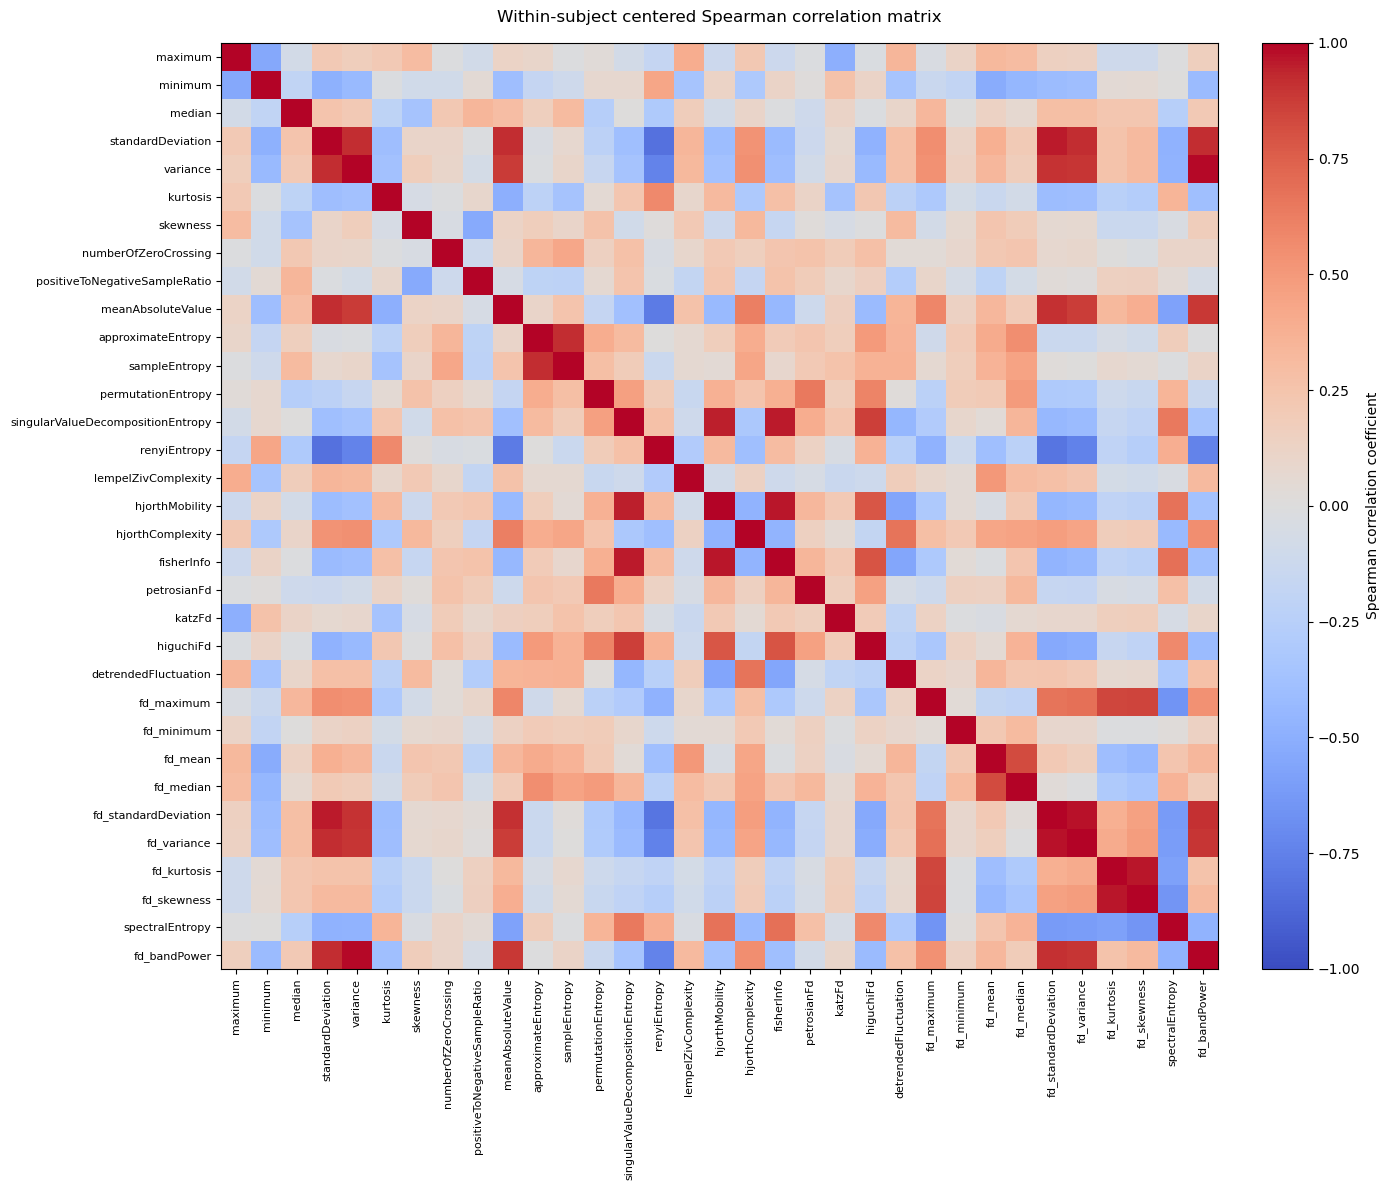

Correlation matrices and heatmap saved to:
/Users/shivangayathri/Library/CloudStorage/OneDrive-Amritauniversity/MyStudents/Asha/Feature Detection for HI/analysis_outputs2


In [18]:

# ============================================================
# 1. Create within-subject centered feature values
# ============================================================

centered_features = (
    df[features]
    - df.groupby(config.subject_col)[features].transform("mean")
)

# ============================================================
# 2. Identify features with no within-subject variation
# ============================================================

centered_variance = centered_features.var()

valid_features = centered_variance[
    centered_variance > np.finfo(float).eps
].index.tolist()

excluded_features = centered_variance[
    centered_variance <= np.finfo(float).eps
].index.tolist()

print("Number of valid features:", len(valid_features))
print("Excluded zero-variance features:", excluded_features)

# Display diagnostic information for excluded features
if excluded_features:
    display(
        pd.DataFrame({
            "feature": excluded_features,
            "centered_variance": centered_variance.loc[
                excluded_features
            ].values,
            "n_unique_centered_values": [
                centered_features[feature].nunique(dropna=True)
                for feature in excluded_features
            ],
        })
    )

# ============================================================
# 3. Calculate full within-subject centered Spearman matrix
# ============================================================

corr_full = within_subject_centered_correlations(
    df,
    config,
    features,
    method="spearman",
)

display(corr_full.round(2))

corr_full.to_csv(
    OUTPUT_DIR
    / "within_subject_centered_spearman_correlations_full.csv"
)

# ============================================================
# 4. Calculate matrix after excluding zero-variance features
# ============================================================

corr_valid = centered_features[
    valid_features
].corr(method="spearman")

display(corr_valid.round(2))

corr_valid.to_csv(
    OUTPUT_DIR
    / "within_subject_centered_spearman_correlations_valid.csv"
)

# ============================================================
# 5. Plot the valid correlation matrix
# ============================================================

corr_values = corr_valid.to_numpy(dtype=float)

# Mask undefined values, if any remain
masked_corr = np.ma.masked_invalid(corr_values)

# Use a diverging map because correlations range from -1 to +1
cmap = plt.get_cmap("coolwarm").copy()
cmap.set_bad("lightgray")

fig, ax = plt.subplots(figsize=(14, 12))

image = ax.imshow(
    masked_corr,
    cmap=cmap,
    vmin=-1,
    vmax=1,
    aspect="auto",
    interpolation="nearest",
)

# Add feature names to both axes
ax.set_xticks(np.arange(len(corr_valid.columns)))
ax.set_yticks(np.arange(len(corr_valid.index)))

ax.set_xticklabels(
    corr_valid.columns,
    rotation=90,
    fontsize=8,
)

ax.set_yticklabels(
    corr_valid.index,
    fontsize=8,
)

ax.set_title(
    "Within-subject centered Spearman correlation matrix",
    pad=15,
)

# Add color scale
colorbar = fig.colorbar(
    image,
    ax=ax,
    fraction=0.046,
    pad=0.04,
)

colorbar.set_label("Spearman correlation coefficient")

fig.tight_layout()

# Save high-resolution figure
heatmap_path = (
    OUTPUT_DIR
    / "within_subject_centered_spearman_heatmap.png"
)

fig.savefig(
    heatmap_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print("Correlation matrices and heatmap saved to:")
print(OUTPUT_DIR.resolve())

### Interpretation of within-subject centered Spearman correlation analysis

This analysis examined correlations between ECG features after centering each feature within each subject. The purpose was to reduce the influence of between-patient baseline differences and identify features that carry overlapping information within patients.

The correlation matrix included **33 valid features**. Features with no usable within-subject variation were excluded from this valid matrix.

---

#### Main finding

Several ECG features were highly correlated after within-subject centering. This means that many extracted features are not independent and likely represent the same underlying signal properties.

There were:

* **15 feature pairs** with absolute Spearman correlation ≥ 0.90;
* **26 feature pairs** with absolute Spearman correlation ≥ 0.80;
* **32 feature pairs** with absolute Spearman correlation ≥ 0.70.

This supports using a compact candidate feature set rather than interpreting all 35 features separately.

---

#### Strong amplitude and spectral-energy redundancy

The strongest redundancy was observed among amplitude and frequency-domain power features.

Highly correlated pairs included:

* `variance` and `fd_bandPower`: ρ = `0.985`
* `fd_standardDeviation` and `fd_variance`: ρ = `0.973`
* `standardDeviation` and `fd_standardDeviation`: ρ = `0.956`
* `standardDeviation` and `meanAbsoluteValue`: ρ = `0.920`
* `standardDeviation` and `variance`: ρ = `0.915`
* `standardDeviation` and `fd_bandPower`: ρ = `0.916`

This indicates that standard deviation, variance, mean absolute value, frequency-domain variance, frequency-domain standard deviation, and band power largely describe the same amplitude/energy-related behavior.

Therefore, these should not be treated as independent candidate biomarkers.

---

#### Strong nonlinear complexity redundancy

A second correlated group involved nonlinear complexity and information features.

Highly correlated pairs included:

* `hjorthMobility` and `fisherInfo`: ρ = `0.967`
* `singularValueDecompositionEntropy` and `fisherInfo`: ρ = `0.954`
* `singularValueDecompositionEntropy` and `hjorthMobility`: ρ = `0.946`
* `singularValueDecompositionEntropy` and `higuchiFd`: ρ = `0.866`
* `fisherInfo` and `higuchiFd`: ρ = `0.794`
* `hjorthMobility` and `higuchiFd`: ρ = `0.785`

This suggests that several nonlinear features capture related aspects of ECG dynamical structure.

---

#### Approximate entropy and sample entropy are highly redundant

`approximateEntropy` and `sampleEntropy` were strongly correlated:

* ρ = `0.916`

This means they likely reflect a similar physiological or signal-processing property. Since `sampleEntropy` showed stronger patient-level evidence in the paired analysis, it may be preferable to use `sampleEntropy` as the representative entropy feature.

`approximateEntropy` can still be reported as supportive, but both should not be interpreted as independent discoveries.

---

#### Candidate feature relationships

Among the main candidate features:

* `sampleEntropy` and `approximateEntropy` were highly correlated: ρ = `0.916`
* `detrendedFluctuation` and `hjorthComplexity` were moderately correlated: ρ = `0.668`
* `sampleEntropy` and `detrendedFluctuation` were only moderately correlated: ρ = `0.364`
* `maximum` was weakly correlated with `sampleEntropy`: ρ = `-0.010`
* `maximum` was weakly correlated with `approximateEntropy`: ρ = `0.100`
* `maximum` was weakly to moderately correlated with `detrendedFluctuation`: ρ = `0.338`

This suggests that `maximum` captures a different signal property from the entropy-based features. Therefore, if retained, it may provide complementary amplitude-related information.

---

#### Frequency-domain mean and median are redundant

The frequency-domain features `fd_mean` and `fd_median` were strongly correlated:

* ρ = `0.826`

This suggests that both describe similar frequency-location behavior. Because `fd_median` showed larger patient-level disagreements, it may be less stable as a candidate feature than other nonlinear features.

---

#### Implication for feature selection

The correlation results suggest that the final exploratory feature set should be compact and avoid redundant features.

A reasonable candidate grouping would be:

1. **Entropy/irregularity representative**

   * Prefer `sampleEntropy`
   * Treat `approximateEntropy` as supportive or redundant

2. **Scaling/complexity representative**

   * Consider `detrendedFluctuation`
   * Possibly include `hjorthComplexity` as supportive

3. **Amplitude representative**

   * Consider `maximum`, but interpret cautiously because of patient-level disagreement in subject `30071`

4. **Frequency-location features**

   * Treat `fd_mean` and `fd_median` cautiously because they are correlated and showed patient-specific instability

---

#### Manuscript interpretation

A suitable interpretation is:

> Within-subject centered Spearman correlation analysis showed substantial redundancy among the extracted ECG features. Amplitude and spectral-energy features formed a highly correlated cluster, while several nonlinear complexity features also showed strong intercorrelations. Approximate entropy and sample entropy were highly correlated, suggesting that they should not be interpreted as independent markers. These findings support reducing the exploratory candidate set to a small number of representative features, with sample entropy, detrended fluctuation analysis, and maximum amplitude capturing partially distinct aspects of ECG signal behavior during HI.


## 9. Save reproducible analysis tables


In [19]:
save_tables(OUTPUT_DIR, cohort, paired_results, lmm_results)
subject_state.to_csv(OUTPUT_DIR / "subject_state_medians.csv", index=False)
comparison.to_csv(OUTPUT_DIR / "paired_lmm_comparison.csv", index=False)

print("Saved outputs to:", OUTPUT_DIR.resolve())


Saved outputs to: /Users/shivangayathri/Library/CloudStorage/OneDrive-Amritauniversity/MyStudents/Asha/Feature Detection for HI/analysis_outputs2


## Overall conclusion from the 11-subject analysis

This analysis should be interpreted as an **exploratory ECG signal-characterization study**, not as a completed biomarker-validation study. The goal was to identify ECG features that show plausible and reproducible within-patient changes during hemodynamic instability (HI), while avoiding overinterpretation from repeated ECG windows.

Across the paired subject-level analysis, supportive mixed-effects modeling, patient-level disagreement analysis, and within-subject correlation analysis, the most defensible candidate features were:

1. **Sample entropy**
2. **Detrended fluctuation analysis**
3. **Approximate entropy**
4. **Hjorth complexity**
5. **Maximum amplitude**

Among these, **sample entropy appears to be the strongest overall candidate**.

---

### Top candidate feature: Sample entropy

`sampleEntropy` is the strongest candidate because it showed evidence across multiple analyses.

In the paired subject-level analysis, sample entropy decreased during HI in most subjects and had one of the strongest uncorrected paired effects. It also showed a large negative rank-biserial effect size. In the supportive LMM analysis, sample entropy showed a strong and highly significant negative condition effect. The paired and LMM analyses agreed in direction, suggesting that the feature decreases during HI at both the patient-summary and window levels.

The patient-level disagreement analysis showed that the subjects who moved against the dominant direction had only small increases. This makes the disagreement less concerning.

Overall, this suggests that HI may be associated with a reduction in ECG signal irregularity or complexity, as captured by sample entropy.

**Conclusion:** `sampleEntropy` should be considered the leading exploratory candidate feature for HI detection.

---

### Second candidate: Detrended fluctuation analysis

`detrendedFluctuation` also showed strong evidence of decrease during HI.

It had one of the strongest paired effect sizes and showed agreement between the paired analysis and the mixed-effects analysis. The LMM also showed a strong negative condition effect. This suggests that HI may be associated with altered scaling behavior or reduced long-range structure in the ECG signal.

However, the patient-level consistency was not perfect because several subjects showed no change. Therefore, DFA is promising, but should be interpreted as slightly less stable than sample entropy.

**Conclusion:** `detrendedFluctuation` is a strong secondary nonlinear candidate.

---

### Third candidate: Approximate entropy

`approximateEntropy` showed a strong decrease in the LMM analysis and agreed in direction with the paired analysis. It supports the same general interpretation as sample entropy: reduced ECG irregularity or complexity during HI.

However, approximate entropy was highly correlated with sample entropy in the within-subject Spearman correlation analysis. Therefore, it likely does not provide independent information from sample entropy.

Because sample entropy showed stronger patient-level support, approximate entropy should be treated as a supportive or redundant entropy feature rather than a separate primary candidate.

**Conclusion:** `approximateEntropy` supports the entropy-based finding, but `sampleEntropy` is the preferred representative entropy feature.

---

### Fourth candidate: Hjorth complexity

`hjorthComplexity` decreased during HI in most subjects and showed agreement between the paired and LMM analyses. This supports the broader observation that ECG complexity-related features tend to decrease during HI.

However, its effect was weaker than sample entropy and detrended fluctuation analysis. It also showed some patient-level disagreement.

**Conclusion:** `hjorthComplexity` is a useful supportive complexity feature, but not the strongest standalone candidate.

---

### Fifth candidate: Maximum amplitude

`maximum` remains a useful amplitude-related candidate because it decreased during HI in most subjects and showed agreement between the paired and LMM analyses.

However, compared with the earlier 6-subject analysis, its importance decreased after adding more patients. The patient-level disagreement analysis showed that one subject had a large opposing increase in maximum amplitude. This suggests that `maximum` may be sensitive to patient-specific amplitude effects, electrode placement, artifact, or physiological heterogeneity.

Unlike the entropy features, `maximum` was weakly correlated with sample entropy and approximate entropy. Therefore, it may provide complementary information as an amplitude-related feature.

**Conclusion:** `maximum` should be retained as a secondary amplitude feature, but interpreted cautiously.

---

### Features that should be deprioritized

Some features showed promising results in one analysis but were less reliable overall.

`kurtosis` was strong in the paired analysis, increasing in most subjects, but it disagreed with the LMM direction and was not significant in the mixed-effects model. Because the patient-level and window-level evidence did not align, kurtosis should not be treated as a primary candidate without further investigation.

Frequency-domain features such as `fd_mean` and `fd_median` showed patient-specific instability and direction disagreements. They may reflect patient-specific spectral shifts rather than consistent HI-related changes.

Highly correlated amplitude and energy features such as `standardDeviation`, `variance`, `fd_variance`, `fd_standardDeviation`, and `fd_bandPower` should not be interpreted as independent markers because the correlation analysis showed substantial redundancy among them.

---

## Recommended candidate feature set

Based on the combined evidence, the most reasonable compact exploratory feature set is:

1. `sampleEntropy`
   Primary entropy/irregularity feature.

2. `detrendedFluctuation`
   Scaling/long-range structure feature.

3. `maximum`
   Complementary amplitude-related feature.

A slightly broader candidate set could include:

4. `approximateEntropy`
   Supportive entropy feature, but likely redundant with sample entropy.

5. `hjorthComplexity`
   Supportive complexity feature.

For manuscript framing, the preferred statement is:

> The most consistent exploratory ECG changes during HI involved reductions in nonlinear complexity and irregularity measures, particularly sample entropy and detrended fluctuation analysis, with additional supportive evidence for reduced maximum amplitude. These features should be considered candidate signal descriptors rather than validated biomarkers.

---

## Are these features ready to detect HI?

These features are promising, but they should not yet be described as validated HI detection biomarkers.

The current analysis supports the statement that these features are associated with HI in this 11-subject cohort. It does not yet prove that they can reliably detect HI in new patients.

The evidence is strongest for exploratory signal characterization and hypothesis generation.

A cautious interpretation is:

> These results suggest that HI is associated with reduced ECG complexity and altered amplitude structure. Sample entropy, detrended fluctuation analysis, and maximum amplitude are the most promising candidate features for future HI detection models, but their diagnostic performance must be validated in a larger independent cohort.

---

## Next steps from a signal-processing perspective

The next step is to determine whether the observed feature changes reflect true physiological signal changes rather than preprocessing artifacts, window-selection effects, or patient-specific recording differences.

Recommended signal-processing steps are:

1. **Inspect raw ECG segments for candidate features**

   For subjects with strong or opposing changes, visually inspect the raw before-HI and during-HI ECG windows. This is especially important for `maximum`, because amplitude features may be affected by electrode placement, noise, clipping, motion artifact, or baseline wander.

2. **Add signal-quality indices**

   Each ECG window should have a signal-quality score. Candidate features should be reanalyzed after excluding low-quality windows. This will show whether the observed changes persist in clean ECG only.

3. **Perform preprocessing sensitivity analysis**

   Repeat feature extraction using different reasonable preprocessing choices, such as different filters, baseline-wander removal methods, artifact rejection thresholds, and normalization strategies. A robust candidate should remain directionally stable.

4. **Evaluate patient-specific normalization**

   Features should be tested using robust patient-specific baseline normalization, using each patient’s before-HI median and MAD. This will help determine whether HI is associated with deviation from the patient’s own baseline.

5. **Perform time-resolved analysis**

   Instead of comparing only before-HI versus during-HI windows, features should be plotted over time relative to HI onset. This will show whether the feature changes gradually before HI, abruptly at HI onset, or only after instability is already present.

6. **Reduce redundant features**

   Because many features were highly correlated, future models should avoid including many redundant descriptors. One representative feature should be selected from each feature family.

A reasonable signal-processing feature set for future work would be:

* one entropy feature: `sampleEntropy`;
* one scaling feature: `detrendedFluctuation`;
* one amplitude feature: `maximum`;
* optionally one additional complexity feature: `hjorthComplexity`.

---

## Next steps from a statistical perspective

The next statistical goal is to move from exploratory association to validation.

Recommended statistical steps are:

1. **Pre-specify the candidate features**

   The next analysis should not test all 35 features equally as new discoveries. The primary features should be pre-specified, for example:

   * `sampleEntropy`
   * `detrendedFluctuation`
   * `maximum`

   This reduces multiple-comparison burden and makes the analysis closer to validation.

2. **Use patient-level inference as the primary evidence**

   The patient should remain the primary statistical unit. Repeated ECG windows should not be treated as independent patients.

3. **Use mixed-effects models only as supportive unless temporal structure is modeled**

   LMMs are useful, but standard random-intercept models may still overstate evidence if adjacent windows are autocorrelated. Future models should consider temporal blocking, random slopes, or autocorrelation-aware approaches.

4. **Perform leave-one-subject-out sensitivity**

   Each candidate feature should be tested after removing one subject at a time. A credible feature should not depend on one patient.

5. **Estimate uncertainty intervals**

   Report confidence intervals or bootstrap intervals for patient-level median differences and effect sizes. This will be more informative than p-values alone.

6. **Validate in an independent cohort**

   True biomarker validation requires testing the pre-specified features in patients who were not used for discovery. Ideally, this should include data from another ICU, recording period, or patient group.

7. **Develop a leakage-free prediction model only after feature confirmation**

   If the goal becomes HI detection, model development should use subject-independent or patient-independent validation. No ECG windows from the same patient should appear in both training and testing sets.

---

## Final interpretation

The 11-subject analysis strengthens the evidence that HI is associated with measurable ECG feature changes, especially reductions in nonlinear complexity and irregularity. The strongest candidate is `sampleEntropy`, followed by `detrendedFluctuation`, with `maximum` providing complementary amplitude-related information.

However, the findings remain exploratory. None of the features survived FDR correction in the primary paired patient-level analysis, and several features showed patient-level heterogeneity. Therefore, the correct conclusion is not that validated biomarkers have been discovered, but that a small set of candidate ECG signal descriptors has been identified for future confirmation and validation.

A suitable manuscript conclusion is:

> In this 11-subject exploratory analysis, hemodynamic instability was associated with candidate reductions in ECG signal irregularity, scaling structure, and maximum amplitude. Sample entropy showed the most coherent evidence across patient-level and mixed-effects analyses, while detrended fluctuation analysis and maximum amplitude provided complementary information. These findings support further investigation of nonlinear ECG features for HI detection, but larger independent validation studies are required before these features can be considered validated biomarkers.
